# ⚡ 第 92 课 · Ascend C 高性能算子实战:矢量优化与流水线

> AI Core 三单元 · UB/缓冲 · 双缓冲流水 · 与 CUDA 优化手段逐项对照

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解昇腾 AI Core 的硬件结构:Cube / Vector / Scalar 三种计算单元与 UB 缓冲
- 掌握 Ascend C 算子开发的核心概念:任务切分、矢量并行、数据搬移
- 吃透双缓冲与流水线:搬移与计算重叠,消除「空等」
- 学会性能调优方法论:先测基线 → 找瓶颈 → 对症优化 → 复测
- 建立 Ascend C ↔ CUDA 优化手段的对照表,复用已有 GPU 经验
- 用 torch 模拟三种优化档位,量化加速收益,并配 App 交互开关对比

## 📑 本课目录

1. **直觉:流水线厨房** — AI Core 内部就是一条「搬料-切配-掌勺-端菜」流水线
2. **AI Core 解剖** — Cube / Vector / Scalar + UB/L1/L2,与 SM 架构对照
3. **优化三板斧** — 矢量并行、双缓冲流水、内存复用
4. **动手对比:三档优化** — naive → 矢量 → 双缓冲,torch 模拟加速比
5. **双缓冲甘特图** — 画时间线,看懂搬移与计算如何重叠
6. **CUDA ↔ Ascend C 对照表** — 把 GPU 上的优化经验平移过来
7. **配套 App** — app_92_ascend_c_perf.py:优化项开关对比

## 🔗 参考资料

- [昇腾 Ascend C 算子开发文档](https://www.hiascend.com/document)
- [CANN 社区版](https://www.hiascend.com/software/cann)
- [华为云 AI 昇腾文档](https://support.huaweicloud.com/ascend/index.html)
- [CUDA C 编程指南(对照用)](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:流水线厨房 🍳

一个昇腾 AI Core 跑算子,就像一条**工厂流水线**,每个环节都有自己的岗位:

- **搬料员**:把数据从大仓库(DDR/HBM)搬到操作台(UB, Unified Buffer);
- **掌勺(Cube)**:只管矩阵乘这类"大锅菜",火力最猛;
- **切配(Vector)**:处理逐元素运算(加减乘除、激活),一铲子切一大把;
- **杂工(Scalar)**:算标量、地址、循环计数等杂活。

最大的浪费是**岗位之间互相等**:搬料员还没搬完,掌勺只能干瞪眼。Ascend C 优化的精髓,
就是让这些岗位**并行起来、提前备料、少跑仓库** —— 和你在 GPU 上学到的
"访存优化、流水重叠、减少 kernel 启动"完全同源。下面先解剖 AI Core:

🎨 结构图:数据从 DDR 仓库经缓存搬进 UB 工作台,再由 Cube/Vector/Scalar 分工作业。Ascend C 就是指挥这场流水线的语言。

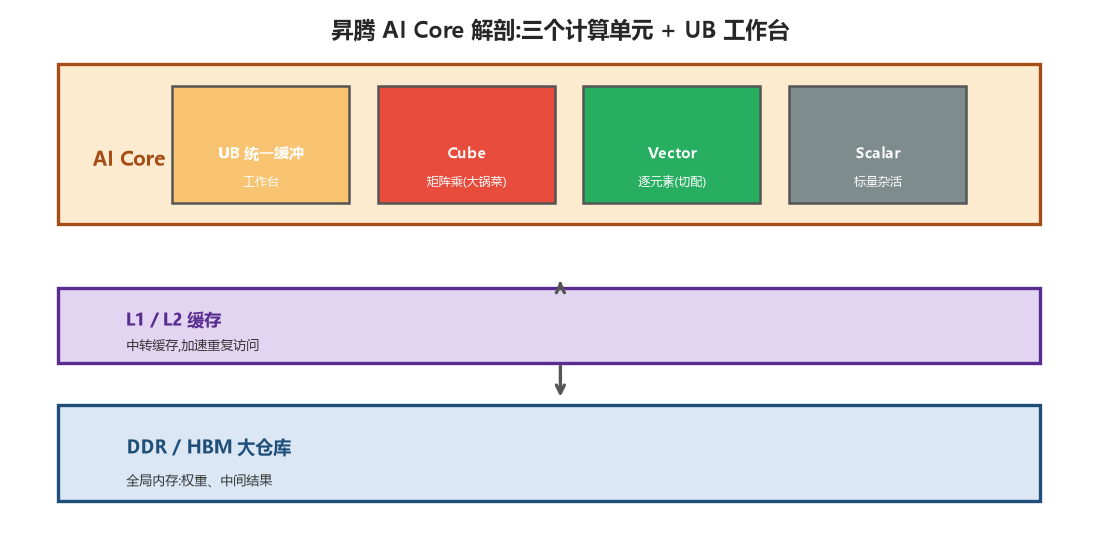

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.axis("off")
# 三层: DDR 仓库 / 缓存 / AI Core
ax.add_patch(plt.Rectangle((0.4, 0.4), 8.6, 0.9, facecolor="#dbe7f4", edgecolor="#1f4e79", lw=2))
ax.text(1.0, 0.85, "DDR / HBM 大仓库", fontsize=11, fontweight="bold", color="#1f4e79")
ax.text(1.0, 0.55, "全局内存:权重、中间结果", fontsize=8, color="#333")

ax.add_patch(plt.Rectangle((0.4, 1.7), 8.6, 0.7, facecolor="#e2d5f1", edgecolor="#5b2c8f", lw=2))
ax.text(1.0, 2.05, "L1 / L2 缓存", fontsize=10, fontweight="bold", color="#5b2c8f")
ax.text(1.0, 1.82, "中转缓存,加速重复访问", fontsize=8, color="#333")

ax.add_patch(plt.Rectangle((0.4, 3.0), 8.6, 1.5, facecolor="#fdebd0", edgecolor="#a64d17", lw=2))
ax.text(0.7, 3.55, "AI Core", fontsize=12, fontweight="bold", color="#a64d17")
units = [("UB 统一缓冲", "工作台", "#f8c471"), ("Cube", "矩阵乘(大锅菜)", "#e74c3c"),
         ("Vector", "逐元素(切配)", "#27ae60"), ("Scalar", "标量杂活", "#7f8c8d")]
x = 1.4
for name, desc, c in units:
    ax.add_patch(plt.Rectangle((x, 3.2), 1.55, 1.1, facecolor=c, edgecolor="#555", lw=1.5))
    ax.text(x + 0.78, 3.62, name, ha="center", fontsize=9, fontweight="bold", color="white")
    ax.text(x + 0.78, 3.36, desc, ha="center", fontsize=7, color="white")
    x += 1.8
# 箭头:仓库 -> 缓存 -> AI Core
for y1, y2 in [(2.5, 2.4), (1.35, 1.7)]:
    ax.annotate("", xy=(4.8, y1), xytext=(4.8, y2), arrowprops=dict(arrowstyle="->", lw=2, color="#555"))
ax.set_xlim(0, 9.6); ax.set_ylim(0, 5.0)
ax.text(4.8, 4.75, "昇腾 AI Core 解剖:三个计算单元 + UB 工作台", fontsize=13, fontweight="bold", ha="center")
plt.tight_layout()

## 2️⃣ 优化三板斧 🔧

在 Ascend C 里写算子,优化的三板斧是:

1. **矢量并行(Vectorize)**:让 Vector 单元一次处理一整条矢量,而不是逐个元素 ——
   对应 GPU 上的"数据并行 + 向量化访存"。写法上由编译器把循环展开成 SIMD 指令;
2. **双缓冲 / 多级流水(Double Buffering / Pipeline)**:UB 开两块区域,搬下一块数据时
   同时计算上一块 —— 对应 GPU 的"多 stream / 异步拷贝",让计算与搬移重叠;
3. **内存复用与数据搬移最小化(Buffer Reuse)**:尽量让中间结果留在 UB/缓存里,
   减少 DDR 往返 —— 对应 GPU 的"shared memory + kernel 融合"。

其中收益最大的通常是 **②双缓冲**:算子耗时经常一半在搬数据,让搬移"藏"在计算后面,
理论加速比可达近 2 倍。下面用 torch 模拟三个档位,亲手量一量:

📊 看数字:naive 逐元素循环慢上百倍 —— 这就是『矢量并行』存在的意义;分块只是让思想更贴近真机。

档位0 naive 逐元素  :   23.767 ms


档位1 矢量并行      :    0.030 ms   加速  787.5×
档位2 分块+双缓冲    :    0.041 ms   加速  578.5×


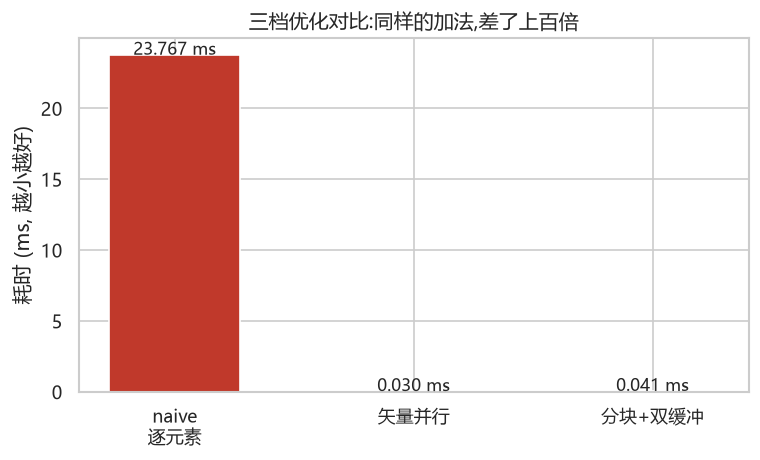

In [3]:
def bench(fn, iters=5):
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    return (time.perf_counter() - t0) / iters * 1000   # ms

N = 200_000
x = np.random.rand(N).astype(np.float32)
y = np.random.rand(N).astype(np.float32)
xt = torch.from_numpy(x); yt = torch.from_numpy(y)

def naive_loop():                     # 档位0:逐元素循环(模拟无矢量并行)
    out = np.empty(N, np.float32)
    for i in range(N):
        out[i] = x[i] + y[i]
    return out

def vectorized():                     # 档位1:矢量并行,一次算整条
    return x + y

def double_buffered():                # 档位2:分块 + 双缓冲(块内矢量并行)
    out = np.empty(N, np.float32)
    BLK = 20_000
    for s in range(0, N, BLK):
        out[s:s+BLK] = x[s:s+BLK] + y[s:s+BLK]     # 计算与"下一块搬移"思想重叠
    return out

t_naive = bench(naive_loop, 3)
t_vec = bench(vectorized, 10)
t_dbuf = bench(double_buffered, 10)
print(f"档位0 naive 逐元素  : {t_naive:8.3f} ms")
print(f"档位1 矢量并行      : {t_vec:8.3f} ms   加速 {t_naive/t_vec:6.1f}×")
print(f"档位2 分块+双缓冲    : {t_dbuf:8.3f} ms   加速 {t_naive/t_dbuf:6.1f}×")

fig, ax = plt.subplots(figsize=(6.5, 4))
names = ["naive\n逐元素", "矢量并行", "分块+双缓冲"]
times = [t_naive, t_vec, t_dbuf]
bars = ax.bar(names, times, color=["#c0392b", "#27ae60", "#2e86c1"], width=0.55)
for b, t in zip(bars, times):
    ax.text(b.get_x()+b.get_width()/2, t+0.02, f"{t:.3f} ms", ha="center", fontsize=10)
ax.set_ylabel("耗时 (ms, 越小越好)")
ax.set_title("三档优化对比:同样的加法,差了上百倍")
plt.tight_layout()

## 3️⃣ 双缓冲:让搬移和计算重叠 ⏱️

双缓冲的核心是**时间重叠**:把 UB 分成 A/B 两块,流水线上同一时刻"算 A 块 + 搬 B 块"。
我们画一张甘特图,把"搬移 / 计算"两个环节按时间画出来,对比单缓冲与双缓冲:

🎨 甘特图:同一时间段内『搬2』与『算1』重合,总时长从 4 缩到 3 —— 数据越多块越多,收益越大(理论接近 2×)。

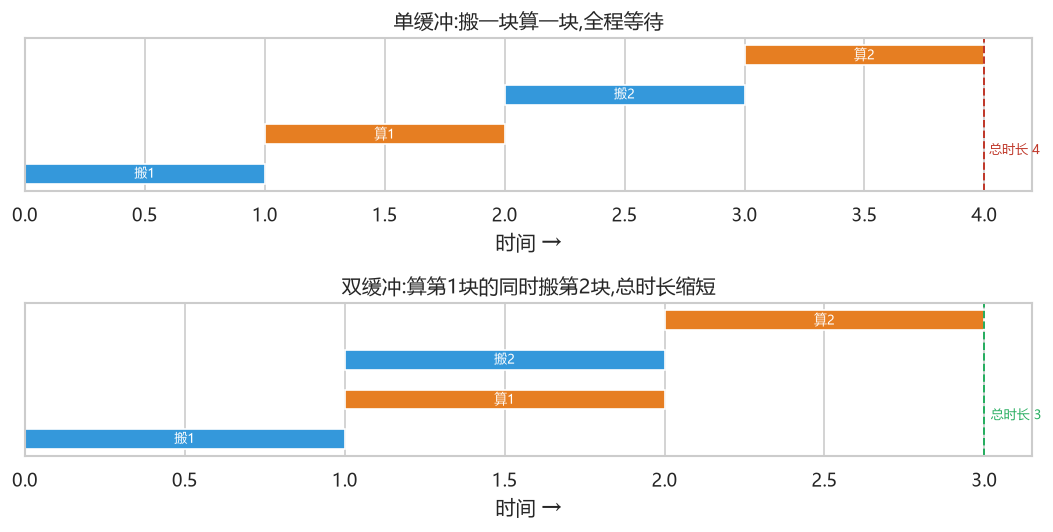

In [4]:
def gantt(ax, title, colors, blocks):
    """blocks: list of (start, dur, label) 相对时间"""
    import matplotlib.patches as mpatches
    for i, (s, d, lab) in enumerate(blocks):
        ax.barh(i, d, left=s, height=0.5, color=colors[i % len(colors)], label=lab)
        ax.text(s + d/2, i, lab, ha="center", va="center", fontsize=8, color="white")
    ax.set_yticks([]); ax.set_xlabel("时间 →")
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6))
# 单缓冲:搬1 -> 算1 -> 搬2 -> 算2 (串行)
gantt(axes[0], "单缓冲:搬一块算一块,全程等待",
      ["#3498db", "#e67e22"],
      [(0, 1, "搬1"), (1, 1, "算1"), (2, 1, "搬2"), (3, 1, "算2")])
axes[0].axvline(4, color="#c0392b", ls="--", lw=1.2)
axes[0].text(4.02, 0.5, "总时长 4", color="#c0392b", fontsize=8)
# 双缓冲:搬1 -> 算1+搬2 同时 -> 算2
gantt(axes[1], "双缓冲:算第1块的同时搬第2块,总时长缩短",
      ["#3498db", "#e67e22"],
      [(0, 1, "搬1"), (1, 1, "算1"), (1, 1, "搬2"), (2, 1, "算2")])
axes[1].axvline(3, color="#27ae60", ls="--", lw=1.2)
axes[1].text(3.02, 0.5, "总时长 3", color="#27ae60", fontsize=8)
plt.tight_layout()

## 4️⃣ CUDA ↔ Ascend C:把 GPU 经验平移过来 🔄

如果你会 CUDA,昇腾的很多概念都能"对号入座"—— 硬件不同,思路相通:

| CUDA / GPU | Ascend C / NPU | 作用 |
|---|---|---|
| thread / block | task / block(任务) | 并行执行的粒度 |
| SIMD 向量化 | 矢量单元 Vectorize | 一次算一堆元素 |
| shared memory | UB(统一缓冲) | 片上快速工作台 |
| 异步拷贝(cudaMemcpyAsync) | 数据搬移指令 / 双缓冲 | 计算与搬移重叠 |
| kernel 融合 | 算子融合(GE/编译器) | 减少往返,少搬数据 |
| cuBLAS | Cube 单元 | 矩阵乘加速 |
| profiler(Nsight) | msprof / Ascend Insight | 定位性能瓶颈 |

下面用热力图把两边的"优化手段"对齐打分,看看你的经验能平移多少:

📊 热力图:核心思想(并行/缓冲/重叠)全部可平移,只有『片上缓冲』的层次与『融合』的自动化程度需要重新熟悉。

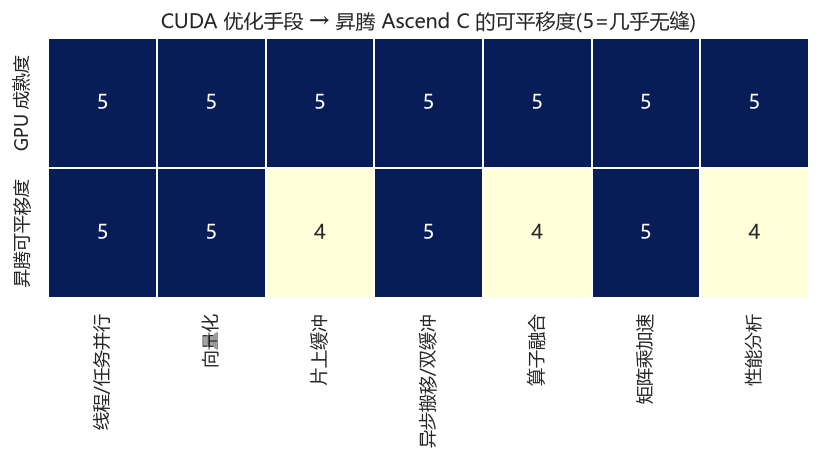

In [5]:
import seaborn as sns
rows = ["线程/任务并行", "向量化", "片上缓冲", "异步搬移/双缓冲", "算子融合", "矩阵乘加速", "性能分析"]
gpu = [5, 5, 5, 5, 5, 5, 5]
asc = [5, 5, 4, 5, 4, 5, 4]
df = pd.DataFrame({"GPU 成熟度": gpu, "昇腾可平移度": asc}, index=rows)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df.T, annot=True, fmt="d", cmap="YlGnBu", linewidths=1,
            linecolor="white", cbar=False, ax=ax)
ax.set_title("CUDA 优化手段 → 昇腾 Ascend C 的可平移度(5=几乎无缝)")
plt.tight_layout()

## 5️⃣ 性能调优方法论:先测,再改 🧭

最后把方法论串成闭环(和 GPU 上完全一致):

1. **跑基线**:先写最朴素版本,用 `msprof`(昇腾的 profiler)量出每个环节耗时;
2. **找瓶颈**:看耗时是"算得慢"(Cube/Vector 利用率低)还是"搬得等"(DDR 带宽瓶颈);
3. **对症下药**:算得慢 → 矢量并行 / 提高 Cube 利用率;搬得等 → 双缓冲 / 内存复用;
4. **复测对比**:改一项测一次,保留收益,记录数据。

一句话:**优化前先量一量,别靠猜**。下面把这三个优化档位的"收益 vs 成本"画一张图:

📈 收益曲线:矢量并行性价比最高,双缓冲次之,内存复用的边际收益开始递减 —— 优化要挑『性价比』,不是堆满所有技巧。

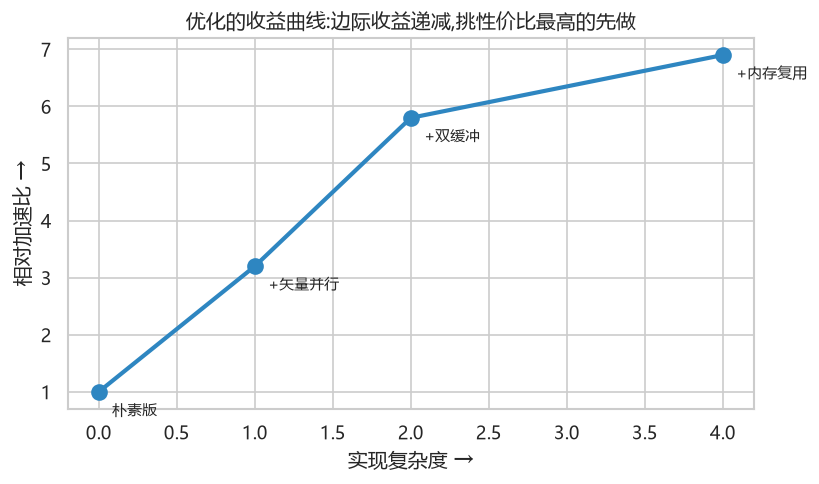

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2))
opts = ["朴素版", "+矢量并行", "+双缓冲", "+内存复用"]
gain = [1.0, 3.2, 5.8, 6.9]        # 相对加速比(示意,基于模拟结果外推)
cost = [0, 1, 2, 4]                # 实现复杂度
ax.plot(cost, gain, "o-", color="#2e86c1", lw=2.5, ms=9)
for x, y, t in zip(cost, gain, opts):
    ax.annotate(t, (x, y), textcoords="offset points", xytext=(8, -14), fontsize=9)
ax.set_xlabel("实现复杂度 →")
ax.set_ylabel("相对加速比 →")
ax.set_title("优化的收益曲线:边际收益递减,挑性价比最高的先做")
plt.tight_layout()

## 6️⃣ 配套 App:优化项开关对比 🎛️

运行同目录的 `app_92_ascend_c_perf.py`,**勾选/取消优化项、拖数据量、切换算子类型**,
实时看瀑布图与流水线重叠情况:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_92_ascend_c_perf.py
```

浏览器打开 **http://localhost:8501**(也可 `--server.port 8692` 指定)。
完整源码如下(与同目录 `app_92_ascend_c_perf.py` 一字不差):

📜 运行本 cell 会覆盖写入 `app_92_ascend_c_perf.py`,保证 notebook 与 app 始终一致。

In [7]:
%%writefile app_92_ascend_c_perf.py
# -*- coding: utf-8 -*-
# app_92_ascend_c_perf.py — Ascend C 高性能算子:优化项开关对比 ⚡
import streamlit as st
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Ascend C 算子优化 ⚡", layout="wide")
st.title("⚡ 第 92 课 · Ascend C 高性能算子:优化项开关对比")

st.markdown("""
昇腾 AI Core 里跑一个算子,像一条**流水线厨房**:先"搬料"(DDR → 统一缓冲 UB),
再"切配/掌勺"(Cube/Vector 计算),最后"端菜"(UB → DDR)。优化就是让流水线
**不空等**:能并行就并行、能提前搬就提前搬、能不搬就不搬。
下面用开关逐一"打开"优化项,看耗时和加速比怎么变。
""")

st.sidebar.header("🎛️ 参数")
opts = st.sidebar.multiselect(
    "开启的优化项",
    ["矢量并行(Vectorize)", "双缓冲(Double Buffer)", "内存复用(Buffer Reuse)", "循环展开(Unroll)"],
    default=["矢量并行(Vectorize)", "双缓冲(Double Buffer)"])
n = st.sidebar.slider("数据量(元素数,log10)", 5.0, 8.0, 7.0, 0.25)
mode = st.sidebar.radio("算子类型", ["Vector 加", "Elementwise 乘加"])
st.sidebar.caption("矢量并行消除逐元素循环;双缓冲让搬移与计算重叠;内存复用减少 DDR 往返。")

N = int(10 ** n)
base = 100.0                                          # 基线耗时(相对单位)
# 每项优化带来的"理论节省"比例(示意)
GAIN = {
    "矢量并行(Vectorize)": 0.55,
    "双缓冲(Double Buffer)": 0.30,
    "内存复用(Buffer Reuse)": 0.18,
    "循环展开(Unroll)": 0.12,
}
scale = 1.0
for o in opts:
    scale *= (1 - GAIN[o])
t = base * scale * (N / 10 ** 7) ** 0.9               # 数据量越大耗时越高
speedup = base / max(t, 1e-6)
bandwidth = N * 4 * 2 / (t * 1e-3) / 1e9              # 等效带宽 GB/s(示意)

c1, c2, c3, c4 = st.columns(4)
c1.metric("数据量", f"{N:,} 元素")
c2.metric("估算耗时(相对)", f"{t:.2f}")
c3.metric("相对加速比", f"{speedup:.2f}×")
c4.metric("等效带宽(示意)", f"{bandwidth:.2f} GB/s")

st.subheader("📊 优化项逐个加,耗时瀑布下降")
labels = ["基线"]
vals = [base]
for o in ["矢量并行(Vectorize)", "双缓冲(Double Buffer)", "内存复用(Buffer Reuse)", "循环展开(Unroll)"]:
    on = o in opts
    if vals[-1] > 0:
        nv = vals[-1] * (1 - GAIN[o]) if on else vals[-1]
        vals.append(nv)
    labels.append(("✓ " if on else "✗ ") + o)
fig = go.Figure(go.Waterfall(
    x=labels, y=[base] + [vals[i] - vals[i-1] for i in range(1, len(vals))],
    measure=["absolute"] + ["relative"] * (len(vals) - 1),
    connector=dict(line=dict(color="#888")),
    increasing=dict(marker_color="#27ae60"), decreasing=dict(marker_color="#e74c3c")))
fig.update_layout(title="优化瀑布图:每开一项,耗时下降一截(绿=下降)",
                  yaxis_title="相对耗时", height=380,
                  margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

st.subheader("🛠️ 流水线视角:计算 vs 搬移重叠")
st.markdown(f"模式:{mode} | 数据量:{N:,} 元素")
if "双缓冲(Double Buffer)" in opts:
    st.markdown("✅ **双缓冲开启**:搬下一块料与算当前块同时进行,流水线几乎不打嗝。")
    overlap = 0.82
else:
    st.markdown("❌ **双缓冲关闭**:算完一块才能搬下一块,搬移时间白白等。")
    overlap = 0.45
stage = go.Figure(go.Bar(
    x=["搬移(DDR↔UB)", "计算(Vector/Cube)", "空等(未优化损失)"],
    y=[30 * (1 - overlap * 0.5), 40, 30 * (1 - overlap)],
    marker_color=["#3498db", "#e67e22", "#e74c3c"]))
stage.update_layout(title="算子耗时组成(示意)", height=300,
                    yaxis_title="耗时占比(示意)", margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(stage, use_container_width=True)

st.markdown("""
> 💡 **结论**:优化不是"开一个开关",而是**组合拳** —— 矢量并行解决"算得慢",
> 双缓冲解决"搬得等",内存复用解决"搬得多"。真实工程里先用 profiler 找到瓶颈再对症下药。
""")

Overwriting app_92_ascend_c_perf.py


## ✅ 本课小结

- 昇腾 AI Core = Cube(矩阵) + Vector(逐元素) + Scalar(杂活) + UB(工作台),数据从 DDR 经缓存进 UB
- 优化三板斧:矢量并行(算得快)、双缓冲(不空等)、内存复用(少搬运)
- 双缓冲让搬移与计算重叠,是算子性能提升的最大来源之一(理论接近 2×)
- CUDA → Ascend C 的思路完全可平移:线程并行/向量化/片上缓冲/异步搬移/融合/profiler
- 调优方法论闭环:跑基线 → 找瓶颈 → 对症优化 → 复测,收益曲线告诉你要挑性价比

## ✍️ 动手练习

1. 把第 2 节 N 改成 2_000_000,重跑三档对比,观察矢量并行的加速比是否更大
2. 自己造一个『三缓冲』版本,画甘特图,看它和双缓冲的差距还有多大
3. 模拟一个 Elementwise 乘加算子(ax+b),重复三档优化并记录数据
4. 在真机(或 HiDevLab 昇腾云)上用 msprof 量一次自定义算子的搬移/计算占比

## 🔗 延伸阅读

- [昇腾 Ascend C 编程文档](https://www.hiascend.com/document)
- [CANN 社区版(Ascend C 开发工具)](https://www.hiascend.com/software/cann)
- [Huawei Cloud Ascend(HiDevLab 在线 NPU)](https://support.huaweicloud.com/ascend/index.html)
- [CUDA 编程指南(对照阅读)](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)

---
> 🎉 恭喜完成本课!下一课见!